# 0. Time Series Analysis — Stock Prices  
**Student:** Dalali Shiva Kumar  
**File:** `C:\Users\DALALI SHIVA KUMAR\Downloads\Raw data stock prices.xlsx`  
**Note:** Run cells in order. This notebook auto-detects company sheets or tickers and runs the full analysis for Tata (first) then Mahindra (second). If a company name is not detected exactly, the code will attempt fuzzy matches and show available keys.


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import os, warnings, re
warnings.filterwarnings("ignore")
print("Libraries imported.")


Libraries imported.


# 2. Load Workbook & Detect Structure
Load the Excel workbook and detect whether it has multiple sheets (one company per sheet) or a single sheet (possibly with a ticker/company column).


In [2]:

# Step 2: Load workbook & detect structure
file_path = r"C:\Users\DALALI SHIVA KUMAR\Downloads\Raw data stock prices.xlsx"  # update if needed
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Workbook sheets detected:", sheet_names)

# Build initial companies dict (raw)
companies = {}
if len(sheet_names) > 1:
    for s in sheet_names:
        companies[s] = pd.read_excel(file_path, sheet_name=s)
    print("Loaded each sheet into `companies` dict (sheet_name -> DataFrame).")
else:
    df_all = pd.read_excel(file_path, sheet_name=0)
    # try detect ticker/company column
    cols_lower = [c.lower() for c in df_all.columns]
    id_col = None
    for cand in ['ticker','symbol','company','name']:
        if cand in cols_lower:
            id_col = df_all.columns[cols_lower.index(cand)]
            break
    if id_col is not None:
        for uid in df_all[id_col].unique():
            companies[str(uid)] = df_all[df_all[id_col] == uid].copy()
        print(f"Single sheet split by '{id_col}' into companies:", list(companies.keys()))
    else:
        companies['Company_1'] = df_all.copy()
        print("Single sheet treated as single company 'Company_1'.")
print("Initial company keys:", list(companies.keys()))


Workbook sheets detected: ['Tata Motors', 'Mahindra & Mahindra']
Loaded each sheet into `companies` dict (sheet_name -> DataFrame).
Initial company keys: ['Tata Motors', 'Mahindra & Mahindra']


# 3. Inspect Raw Data — (General)
Show shape, columns, head, info, describe, and missing value counts for each raw company sheet.


In [3]:
# Step 3: Inspect raw data for all detected companies
def inspect_raw(name, dframe):
    print(f"\n--- Inspecting raw: {name} ---")
    print("Shape:", dframe.shape)
    print("Columns:", list(dframe.columns))
    print("\nHead:")
    display(dframe.head())
    print("\nInfo:")
    display(dframe.info())
    print("\nDescribe (numeric):")
    display(dframe.describe().T)
    print("\nMissing values:")
    display(dframe.isnull().sum())

for k, v in companies.items():
    inspect_raw(k, v)





--- Inspecting raw: Tata Motors ---
Shape: (1241, 7)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Head:


,Date,Price,Open,High,Low,Vol.,Change %
0,2020-03-12 00:00:00,111.56,111.65,112.25,110.59,33.33M,0.0068
1,2020-04-12 00:00:00,111.14,112.55,113.94,109.96,48.00M,-0.0038
2,2020-07-12 00:00:00,110.77,111.32,112.52,110.26,29.80M,-0.0033
3,2020-08-12 00:00:00,109.72,111.62,112.07,108.00,42.14M,-0.0095
4,2020-09-12 00:00:00,110.26,110.44,112.49,109.63,40.30M,0.0050



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1241 non-null   object 
 1   Price     1241 non-null   float64
 2   Open      1241 non-null   float64
 3   High      1241 non-null   float64
 4   Low       1241 non-null   float64
 5   Vol.      1241 non-null   object 
 6   Change %  1241 non-null   float64
dtypes: float64(5), object(2)
memory usage: 68.0+ KB


None


Describe (numeric):


...

None


Describe (numeric):


,count,mean,std,min,25%,50%,75%,max
Price,1241.0,1758.392184,934.251845,685.9500,889.5000,1378.6500,2759.000,3757.3000
Open,1241.0,1758.895810,934.112487,688.8000,889.8000,1379.0000,2763.000,3790.0000
High,1241.0,1780.915391,945.723134,699.3500,903.8000,1390.0000,2800.000,3795.0000
Low,1241.0,1736.403263,923.229132,660.2500,879.0000,1363.2000,2728.000,3740.0000
Change %,1241.0,0.001434,0.018006,-0.0661,-0.0092,0.0008,0.011,0.0795



Missing values:


Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

# 4. Decide Company Keys (Tata & Mahindra)
We will attempt to detect the exact keys for Tata and Mahindra using robust substring/fuzzy matching. If not found, the code will show available keys and ask you to pick — but it will try multiple patterns automatically.


In [4]:
# Step 4: Detect keys for Tata and Mahindra (robust)
def find_key_by_variants(dict_keys, variants):
    dict_keys_lower = [k.lower() for k in dict_keys]
    for var in variants:
        for i,k in enumerate(dict_keys_lower):
            if var.lower() in k:
                return list(dict_keys)[i]
    # relaxed: split words and check intersection
    for k in dict_keys:
        kparts = re.split(r'[\s&,-]+', k.lower())
        for var in variants:
            varparts = re.split(r'[\s&,-]+', var.lower())
            if any(p in kparts for p in varparts):
                return k
    return None

available_keys = list(companies.keys())
tata_key = find_key_by_variants(available_keys, ['tata', 'tata motors', 'tatamotors', 'tata'])
mahindra_key = find_key_by_variants(available_keys, ['mahindra', 'mahindra & mahindra', 'm&m', 'mm', 'mah'])

print("Detected Tata key:", tata_key)
print("Detected Mahindra key:", mahindra_key)
if tata_key is None or mahindra_key is None:
    print("\nIf either key is None, available keys are:", available_keys)
    print("If detection failed, tell me the exact key name you want to use (copy from the available keys).")


Detected Tata key: Tata Motors
Detected Mahindra key: Mahindra & Mahindra


# 5. Cleaning & Standardisation (robust function)
Define a robust cleaning function used for each company. It will parse Date, set date index, detect price column (Close/Adj Close/Price) safely, parse Volume if present, and drop rows without Price.


In [5]:
# Step 5: Define cleaning function (robust)
def clean_and_standardize(df_raw, date_candidates=None, price_candidates=None):
    dfc = df_raw.copy()
    dfc.columns = [str(c).strip() for c in dfc.columns]
    # date detection
    if date_candidates is None:
        date_candidates = ['date','Date','trade_date','Trade Date','timestamp','Timestamp']
    date_col = None
    for c in dfc.columns:
        if c in date_candidates or c.lower()=='date':
            date_col = c; break
    if date_col is None:
        # fallback: any column with 'date' in name
        for c in dfc.columns:
            if 'date' in c.lower():
                date_col = c; break
    if date_col is None:
        raise ValueError("No Date column found. Please check the Excel columns.")
    dfc[date_col] = pd.to_datetime(dfc[date_col], errors='coerce')
    dfc = dfc.set_index(date_col).sort_index()
    # price detection
    if price_candidates is None:
        price_candidates = ['Close','Price','Adj Close','AdjClose','Adj_Close','close','price','adj close','Close Price']
    price_col = None
    for c in price_candidates:
        if c in dfc.columns:
            price_col = c; break
    if price_col is None:
        # pick numeric column with most non-null values as fallback
        numeric_counts = [(col, pd.to_numeric(dfc[col], errors='coerce').notna().sum()) for col in dfc.columns]
        numeric_counts = sorted(numeric_counts, key=lambda x: -x[1])
        if numeric_counts and numeric_counts[0][1] > 0:
            price_col = numeric_counts[0][0]
            print(f"Warning: auto-detected price-like column '{price_col}'. Please verify.")
        else:
            raise ValueError("No numeric column suitable for Price found.")
    dfc = dfc.rename(columns={price_col: 'Price'})
    # keep relevant columns
    keep_cols = ['Price','Open','High','Low','Volume']
    present_keep = [c for c in keep_cols if c in dfc.columns]
    dfc = dfc[present_keep]
    # parse Volume
    if 'Volume' in dfc.columns:
        def parse_volume(v):
            try:
                if pd.isna(v): return np.nan
                if isinstance(v, str):
                    v2 = v.replace(',', '').upper()
                    v2 = v2.replace('M','e6').replace('K','e3').replace('B','e9')
                    return float(eval(v2))
                return float(v)
            except Exception:
                return np.nan
        dfc['Volume'] = dfc['Volume'].apply(parse_volume)
    # drop rows without price
    dfc = dfc.dropna(subset=['Price'])
    return dfc

print("Cleaning function defined.")


Cleaning function defined.


# 5A. Clean Tata (explicit)
Clean Tata using the function above and save into `companies_clean['<key>']`. This cell will stop with a helpful message if tata key wasn't auto-detected; in that case enter the key name shown above.


In [6]:
# Step 5A: Clean Tata explicitly
if tata_key is None:
    print("Tata key not detected automatically. Available keys:", list(companies.keys()))
    # if you see your desired key in the list, set it manually here, e.g. tata_key = 'Tata Motors'
    # For automatic continuity we'll try best-match again:
    tata_try = find_key_by_variants(list(companies.keys()), ['tata','tata motors','tatamotors','tata'])
    tata_key = tata_try
    print("Retry detected Tata key as:", tata_key)

if tata_key is None:
    raise RuntimeError("Tata key still not found. Copy the exact company key from the above available keys and set `tata_key` variable then re-run this cell.")
# perform cleaning
companies_clean = globals().get('companies_clean', {})
companies_clean[tata_key] = clean_and_standardize(companies[tata_key])
print("Tata cleaned and stored in companies_clean with key:", tata_key)
display(companies_clean[tata_key].head())


Tata cleaned and stored in companies_clean with key: Tata Motors


,Price,Open,High,Low
Date,,,,
2020-03-12,111.56,111.65,112.25,110.59
2020-04-12,111.14,112.55,113.94,109.96
2020-07-12,110.77,111.32,112.52,110.26
2020-08-12,109.72,111.62,112.07,108.00
2020-09-12,110.26,110.44,112.49,109.63


# 5B. Clean Mahindra (explicit)
Clean Mahindra using the function above and save into `companies_clean['<key>']`. If Mahindra wasn't auto-detected the cell will ask for the correct key.


In [7]:
# Step 5B: Clean Mahindra explicitly
if mahindra_key is None:
    print("Mahindra key not detected automatically. Available keys:", list(companies.keys()))
    mah_try = find_key_by_variants(list(companies.keys()), ['mahindra','mahindra & mahindra','m&m','mm','mah'])
    mahindra_key = mah_try
    print("Retry detected Mahindra key as:", mahindra_key)

if mahindra_key is None:
    raise RuntimeError("Mahindra key still not found. Copy the exact company key from the available keys and set `mahindra_key` then re-run this cell.")
# perform cleaning
companies_clean = globals().get('companies_clean', {})
companies_clean[mahindra_key] = clean_and_standardize(companies[mahindra_key])
print("Mahindra cleaned and stored in companies_clean with key:", mahindra_key)
display(companies_clean[mahindra_key].head())


Mahindra cleaned and stored in companies_clean with key: Mahindra & Mahindra


,Price,Open,High,Low
Date,,,,
2020-03-12,745.85,750.05,756.35,743.70
2020-04-12,750.55,749.10,764.45,743.20
2020-07-12,752.30,750.00,755.85,744.05
2020-08-12,754.00,753.35,764.00,743.55
2020-09-12,755.00,756.80,762.95,750.20


# 6A. Inspect Cleaned Data — Tata
Inspect cleaned Tata: shape, head, describe, missing, and quick plot.


Tata key: Tata Motors
Shape: (1241, 4)


,Price,Open,High,Low
Date,,,,
2020-03-12,111.56,111.65,112.25,110.59
2020-04-12,111.14,112.55,113.94,109.96
2020-07-12,110.77,111.32,112.52,110.26
2020-08-12,109.72,111.62,112.07,108.00
2020-09-12,110.26,110.44,112.49,109.63


,count,mean,std,min,25%,50%,75%,max
Price,1241.0,353.731869,136.647803,99.31,252.21,335.40,431.66,703.35
Open,1241.0,354.482337,137.163754,99.31,252.87,331.60,432.84,706.47
High,1241.0,358.565230,138.161869,102.11,255.16,336.16,437.08,713.73
Low,1241.0,349.438195,135.394089,94.57,249.31,324.63,427.61,693.33


Price    0
Open     0
High     0
Low      0
dtype: int64

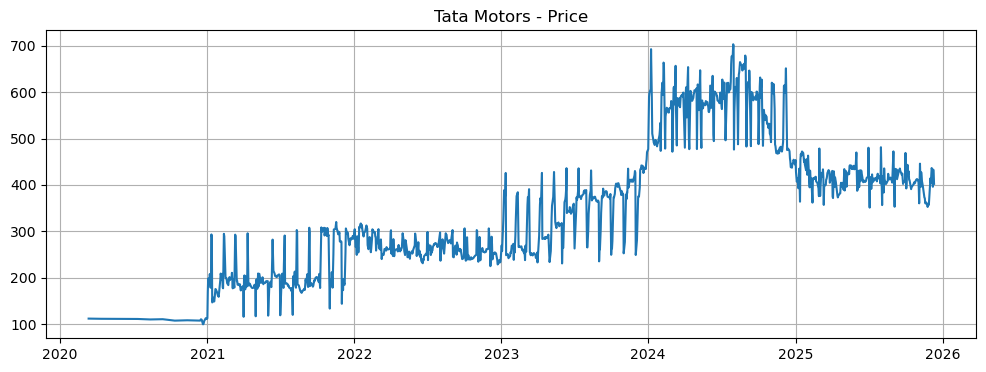

In [8]:
# Step 6A: Inspect cleaned Tata
if tata_key not in companies_clean:
    raise RuntimeError("Tata not found in companies_clean. Run the cleaning cell first.")
tata_df = companies_clean[tata_key]
print("Tata key:", tata_key)
print("Shape:", tata_df.shape)
display(tata_df.head())
display(tata_df.describe().T)
display(tata_df.isnull().sum())
plt.figure(figsize=(12,4)); plt.plot(tata_df.index, tata_df['Price']); plt.title(f"{tata_key} - Price"); plt.grid(True); plt.show()


# 6B. Inspect Cleaned Data — Mahindra
Inspect cleaned Mahindra: shape, head, describe, missing, and quick plot.


Mahindra key: Mahindra & Mahindra
Shape: (1241, 4)


,Price,Open,High,Low
Date,,,,
2020-03-12,745.85,750.05,756.35,743.70
2020-04-12,750.55,749.10,764.45,743.20
2020-07-12,752.30,750.00,755.85,744.05
2020-08-12,754.00,753.35,764.00,743.55
2020-09-12,755.00,756.80,762.95,750.20


,count,mean,std,min,25%,50%,75%,max
Price,1241.0,1758.392184,934.251845,685.95,889.5,1378.65,2759.0,3757.3
Open,1241.0,1758.895810,934.112487,688.80,889.8,1379.00,2763.0,3790.0
High,1241.0,1780.915391,945.723134,699.35,903.8,1390.00,2800.0,3795.0
Low,1241.0,1736.403263,923.229132,660.25,879.0,1363.20,2728.0,3740.0


Price    0
Open     0
High     0
Low      0
dtype: int64

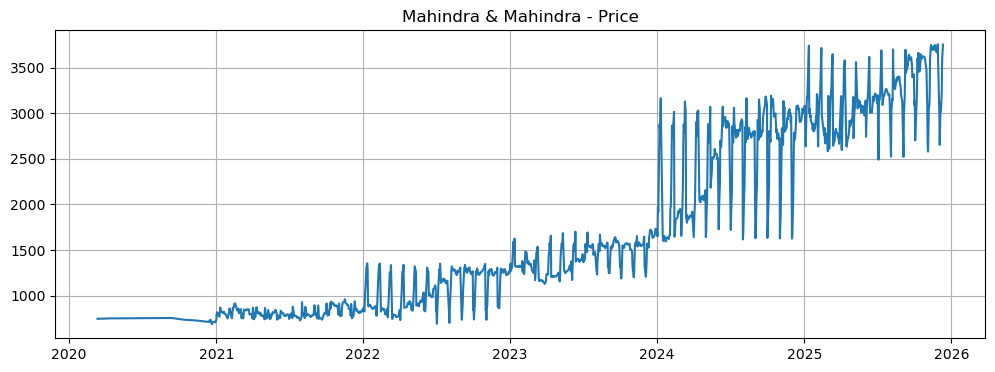

In [9]:
# Step 6B: Inspect cleaned Mahindra
if mahindra_key not in companies_clean:
    raise RuntimeError("Mahindra not found in companies_clean. Run the cleaning cell first.")
mah_df = companies_clean[mahindra_key]
print("Mahindra key:", mahindra_key)
print("Shape:", mah_df.shape)
display(mah_df.head())
display(mah_df.describe().T)
display(mah_df.isnull().sum())
plt.figure(figsize=(12,4)); plt.plot(mah_df.index, mah_df['Price']); plt.title(f"{mahindra_key} - Price"); plt.grid(True); plt.show()


# 7A. Derived Features — Tata
Compute moving averages (7,15,30), daily returns, Return_% and 30-day rolling volatility for Tata.


In [10]:
# Step 7A: Derived features for Tata
def add_derived_features(dfc):
    dfc = dfc.copy()
    dfc['MA_7']  = dfc['Price'].rolling(window=7, min_periods=1).mean()
    dfc['MA_15'] = dfc['Price'].rolling(window=15, min_periods=1).mean()
    dfc['MA_30'] = dfc['Price'].rolling(window=30, min_periods=1).mean()
    dfc['Return'] = dfc['Price'].pct_change()
    dfc['Return_%'] = dfc['Return'] * 100
    dfc['Volatility_30d'] = dfc['Return'].rolling(window=30).std() * np.sqrt(252)
    return dfc

tata_df = add_derived_features(tata_df)
companies_clean[tata_key] = tata_df
print("Derived features added for Tata.")
display(tata_df[['Price','MA_7','MA_15','MA_30','Return_%','Volatility_30d']].head(10))


Derived features added for Tata.


,Price,MA_7,MA_15,MA_30,Return_%,Volatility_30d
Date,,,,,,
2020-03-12,111.56,111.560000,111.560000,111.560000,NaN,NaN
2020-04-12,111.14,111.350000,111.350000,111.350000,-0.376479,NaN
2020-07-12,110.77,111.156667,111.156667,111.156667,-0.332913,NaN
2020-08-12,109.72,110.797500,110.797500,110.797500,-0.947910,NaN
2020-09-12,110.26,110.690000,110.690000,110.690000,0.492162,NaN
2020-10-12,107.18,110.105000,110.105000,110.105000,-2.793397,NaN
2020-11-12,107.94,109.795714,109.795714,109.795714,0.709088,NaN
2020-12-14,107.21,109.174286,109.472500,109.472500,-0.676302,NaN
2020-12-15,107.97,108.721429,109.305556,109.305556,0.708889,NaN


# 7B. Derived Features — Mahindra
Compute moving averages (7,15,30), daily returns, Return_% and 30-day rolling volatility for Mahindra.


In [11]:
# Step 7B: Derived features for Mahindra
mah_df = add_derived_features(mah_df)
companies_clean[mahindra_key] = mah_df
print("Derived features added for Mahindra.")
display(mah_df[['Price','MA_7','MA_15','MA_30','Return_%','Volatility_30d']].head(10))


Derived features added for Mahindra.


,Price,MA_7,MA_15,MA_30,Return_%,Volatility_30d
Date,,,,,,
2020-03-12,745.85,745.850000,745.850000,745.850000,NaN,NaN
2020-04-12,750.55,748.200000,748.200000,748.200000,0.630154,NaN
2020-07-12,752.30,749.566667,749.566667,749.566667,0.233162,NaN
2020-08-12,754.00,750.675000,750.675000,750.675000,0.225974,NaN
2020-09-12,755.00,751.540000,751.540000,751.540000,0.132626,NaN
2020-10-12,736.15,748.975000,748.975000,748.975000,-2.496689,NaN
2020-11-12,727.55,745.914286,745.914286,745.914286,-1.168240,NaN
2020-12-14,711.70,741.035714,741.637500,741.637500,-2.178544,NaN
2020-12-15,717.95,736.378571,739.005556,739.005556,0.878179,NaN


# 8A. Price Chart with Moving Averages — Tata
Plot Price with MA_7, MA_15, MA_30 for Tata.


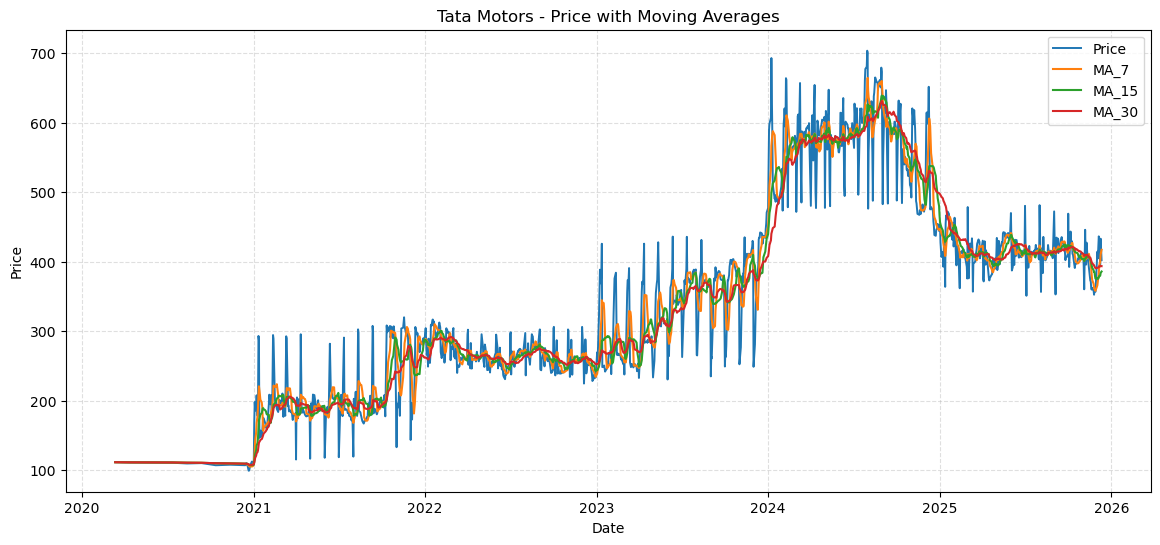

In [12]:
# Step 8A: Plot price + MA for Tata
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(tata_df.index, tata_df['Price'], label='Price', linewidth=1.4)
ax.plot(tata_df.index, tata_df['MA_7'], label='MA_7')
ax.plot(tata_df.index, tata_df['MA_15'], label='MA_15')
ax.plot(tata_df.index, tata_df['MA_30'], label='MA_30')
ax.set_title(f"{tata_key} - Price with Moving Averages"); ax.set_xlabel("Date"); ax.set_ylabel("Price")
ax.grid(True, linestyle='--', alpha=0.4); ax.legend(); plt.show()


# 8B. Price Chart with Moving Averages — Mahindra
Plot Price with MA_7, MA_15, MA_30 for Mahindra.


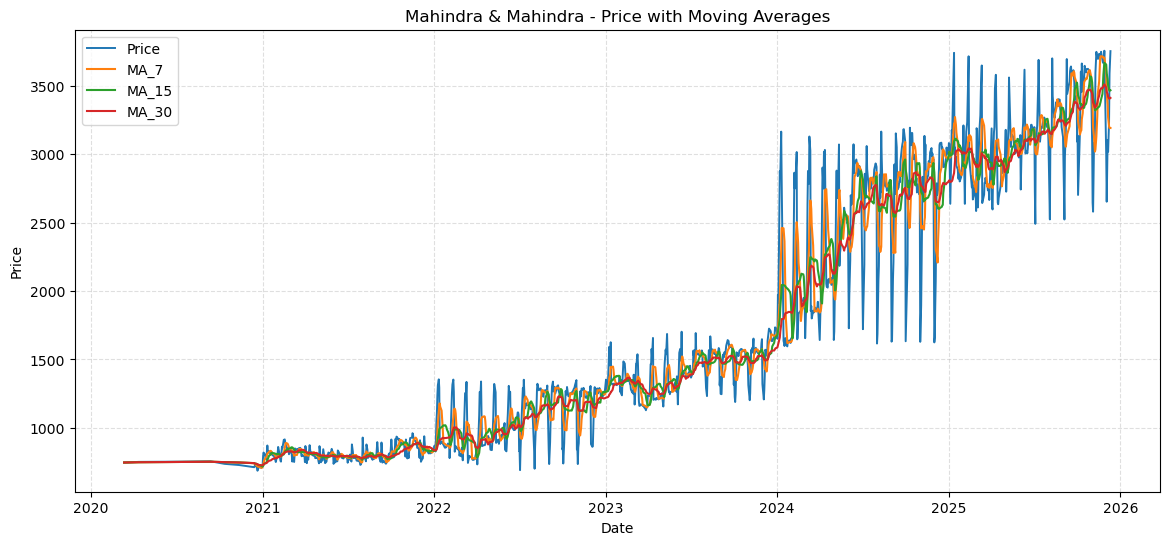

In [13]:
# Step 8B: Plot price + MA for Mahindra
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(mah_df.index, mah_df['Price'], label='Price', linewidth=1.4)
ax.plot(mah_df.index, mah_df['MA_7'], label='MA_7')
ax.plot(mah_df.index, mah_df['MA_15'], label='MA_15')
ax.plot(mah_df.index, mah_df['MA_30'], label='MA_30')
ax.set_title(f"{mahindra_key} - Price with Moving Averages"); ax.set_xlabel("Date"); ax.set_ylabel("Price")
ax.grid(True, linestyle='--', alpha=0.4); ax.legend(); plt.show()


# 9A. Returns & Volatility Plots — Tata
Plot daily returns (%) and rolling volatility for Tata.


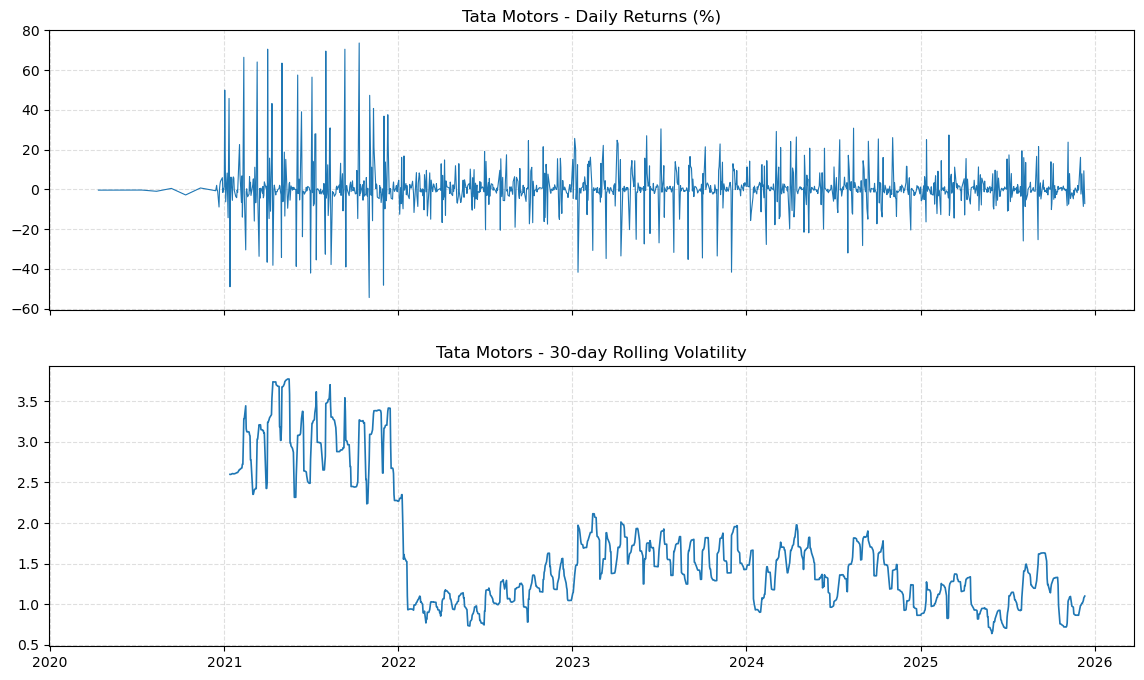

In [14]:
# Step 9A: Returns & volatility for Tata
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True)
ax1.plot(tata_df.index, tata_df['Return_%'], linewidth=0.8); ax1.set_title(f"{tata_key} - Daily Returns (%)"); ax1.grid(True, linestyle='--', alpha=0.4)
ax2.plot(tata_df.index, tata_df['Volatility_30d'], linewidth=1.2); ax2.set_title(f"{tata_key} - 30-day Rolling Volatility"); ax2.grid(True, linestyle='--', alpha=0.4)
plt.show()


# 9B. Returns & Volatility Plots — Mahindra
Plot daily returns (%) and rolling volatility for Mahindra.


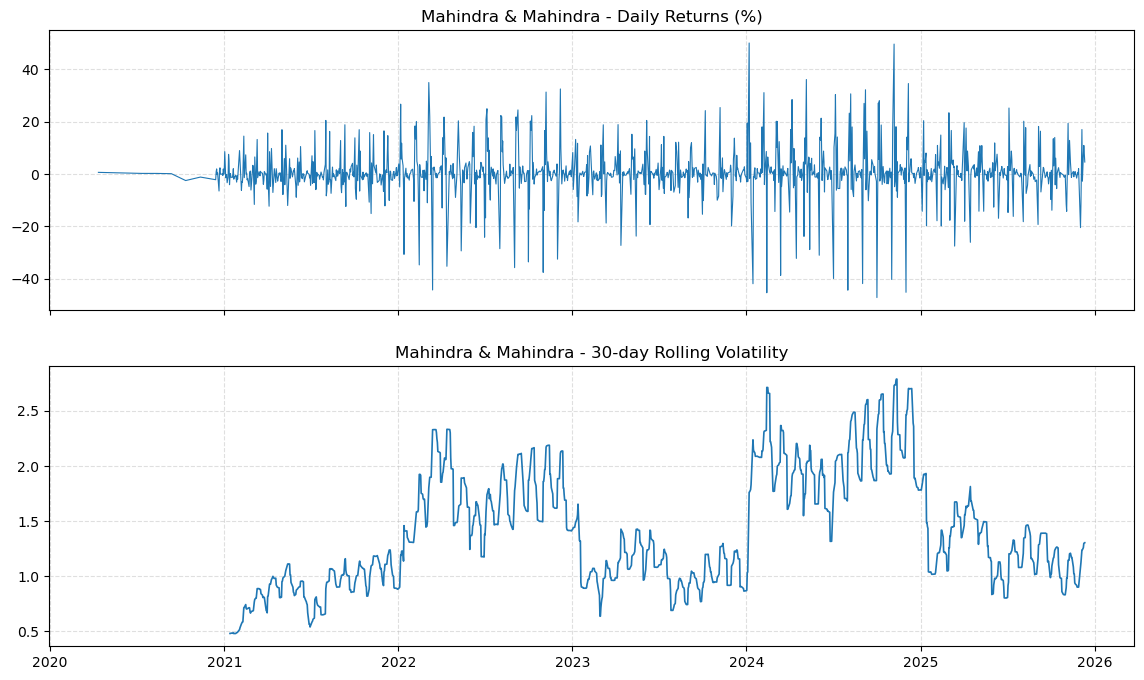

In [15]:
# Step 9B: Returns & volatility for Mahindra
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True)
ax1.plot(mah_df.index, mah_df['Return_%'], linewidth=0.8); ax1.set_title(f"{mahindra_key} - Daily Returns (%)"); ax1.grid(True, linestyle='--', alpha=0.4)
ax2.plot(mah_df.index, mah_df['Volatility_30d'], linewidth=1.2); ax2.set_title(f"{mahindra_key} - 30-day Rolling Volatility"); ax2.grid(True, linestyle='--', alpha=0.4)
plt.show()


# 10A. ACF / PACF and Stationarity Test (ADF) — Tata
Plot ACF/PACF for returns and run ADF on Price and Returns for Tata.


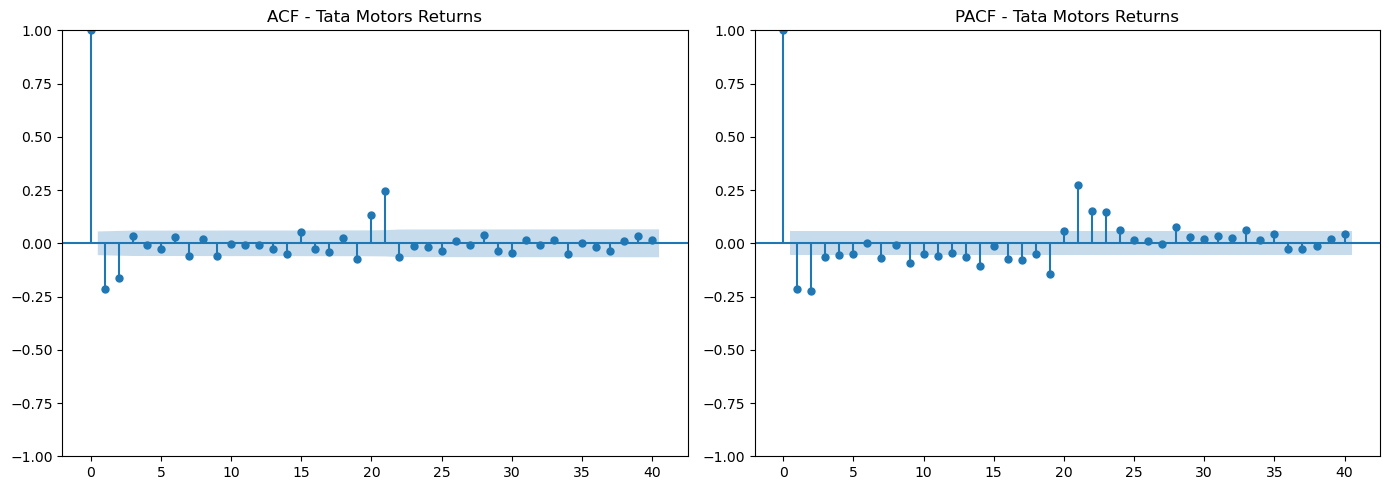

Tata Motors - ADF Price stat: -1.6498, p-value: 0.4571
Tata Motors - ADF Returns stat: -5.8625, p-value: 0.0000


In [16]:
# Step 10A: ACF/PACF and ADF - Tata
ret = tata_df['Return'].dropna()
if len(ret) > 3:
    fig = plt.figure(figsize=(14,5))
    ax1 = fig.add_subplot(121); plot_acf(ret, lags=40, ax=ax1, title=f'ACF - {tata_key} Returns')
    ax2 = fig.add_subplot(122); plot_pacf(ret, lags=40, ax=ax2, method='ywmle', title=f'PACF - {tata_key} Returns')
    plt.tight_layout(); plt.show()
try:
    adf_price = adfuller(tata_df['Price'].dropna())
    print(f"{tata_key} - ADF Price stat: {adf_price[0]:.4f}, p-value: {adf_price[1]:.4f}")
except Exception as e:
    print("ADF Price failed:", e)
try:
    adf_ret = adfuller(tata_df['Return'].dropna())
    print(f"{tata_key} - ADF Returns stat: {adf_ret[0]:.4f}, p-value: {adf_ret[1]:.4f}")
except Exception:
    print(f"{tata_key} - ADF on Returns not available")


# 10B. ACF / PACF and Stationarity Test (ADF) — Mahindra
Plot ACF/PACF for returns and run ADF on Price and Returns for Mahindra.


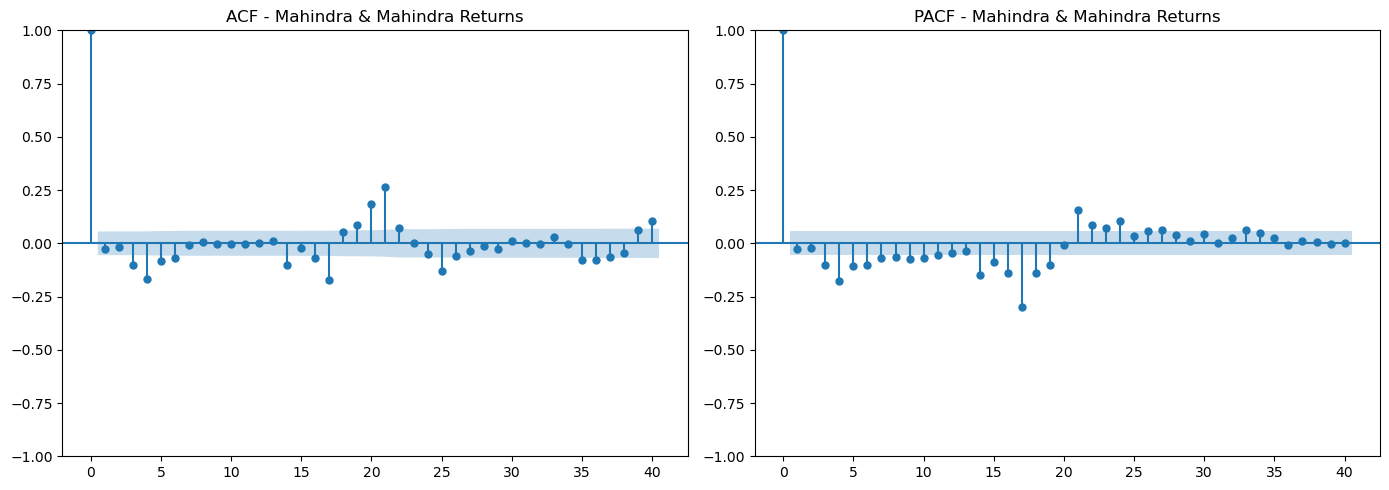

Mahindra & Mahindra - ADF Price stat: 1.2605, p-value: 0.9964
Mahindra & Mahindra - ADF Returns stat: -8.4779, p-value: 0.0000


In [17]:
# Step 10B: ACF/PACF and ADF - Mahindra
ret2 = mah_df['Return'].dropna()
if len(ret2) > 3:
    fig = plt.figure(figsize=(14,5))
    ax1 = fig.add_subplot(121); plot_acf(ret2, lags=40, ax=ax1, title=f'ACF - {mahindra_key} Returns')
    ax2 = fig.add_subplot(122); plot_pacf(ret2, lags=40, ax=ax2, method='ywmle', title=f'PACF - {mahindra_key} Returns')
    plt.tight_layout(); plt.show()
try:
    adf_price2 = adfuller(mah_df['Price'].dropna())
    print(f"{mahindra_key} - ADF Price stat: {adf_price2[0]:.4f}, p-value: {adf_price2[1]:.4f}")
except Exception as e:
    print("ADF Price failed:", e)
try:
    adf_ret2 = adfuller(mah_df['Return'].dropna())
    print(f"{mahindra_key} - ADF Returns stat: {adf_ret2[0]:.4f}, p-value: {adf_ret2[1]:.4f}")
except Exception:
    print(f"{mahindra_key} - ADF on Returns not available")


# 11A. Train/Test Split (80/20) — Tata
Split Tata Price series into train (80%) and test (20%).


In [18]:
# Step 11A: Train/test split - Tata
def train_test_split_series(dfc, split_pct=0.8):
    split_idx = int(len(dfc) * split_pct)
    train = dfc['Price'].iloc[:split_idx]
    test  = dfc['Price'].iloc[split_idx:]
    return train, test

tata_train, tata_test = train_test_split_series(tata_df, 0.8)
print("Tata train length:", len(tata_train), "test length:", len(tata_test))


Tata train length: 992 test length: 249


# 11B. Train/Test Split (80/20) — Mahindra
Split Mahindra Price series into train (80%) and test (20%).


In [19]:
# Step 11B: Train/test split - Mahindra
mah_train, mah_test = train_test_split_series(mah_df, 0.8)
print("Mahindra train length:", len(mah_train), "test length:", len(mah_test))


Mahindra train length: 992 test length: 249


# 12A. Simple Exponential Smoothing (SES) — Tata
Fit SES to Tata train and forecast test period. Report RMSE, MAE, MAPE.


In [20]:
# Step 12A: SES - Tata
tata_ses_model = SimpleExpSmoothing(tata_train).fit()
tata_ses_pred = tata_ses_model.forecast(len(tata_test))
tata_ses_rmse = np.sqrt(mean_squared_error(tata_test.values, tata_ses_pred.values))
tata_ses_mae  = mean_absolute_error(tata_test.values, tata_ses_pred.values)
tata_ses_mape = mean_absolute_percentage_error(tata_test.values, tata_ses_pred.values) * 100
print("Tata SES -> RMSE:", tata_ses_rmse, "MAE:", tata_ses_mae, "MAPE(%):", tata_ses_mape)


Tata SES -> RMSE: 169.74324404908353 MAE: 166.45917952327898 MAPE(%): 40.56888203448448


# 12B. Simple Exponential Smoothing (SES) — Mahindra
Fit SES to Mahindra train and forecast test period. Report RMSE, MAE, MAPE.


In [21]:
# Step 12B: SES - Mahindra
mah_ses_model = SimpleExpSmoothing(mah_train).fit()
mah_ses_pred = mah_ses_model.forecast(len(mah_test))
mah_ses_rmse = np.sqrt(mean_squared_error(mah_test.values, mah_ses_pred.values))
mah_ses_mae  = mean_absolute_error(mah_test.values, mah_ses_pred.values)
mah_ses_mape = mean_absolute_percentage_error(mah_test.values, mah_ses_pred.values) * 100
print("Mahindra SES -> RMSE:", mah_ses_rmse, "MAE:", mah_ses_mae, "MAPE(%):", mah_ses_mape)


Mahindra SES -> RMSE: 1306.4266316881453 MAE: 1265.054984404767 MAPE(%): 39.557129468154876


# 13A. Holt / Exponential Smoothing (Additive) — Tata
Fit Holt additive trend model to Tata train and forecast. Report RMSE, MAE, MAPE.


In [22]:
# Step 13A: Holt - Tata
tata_holt_model = ExponentialSmoothing(tata_train, trend='add', seasonal=None).fit()
tata_holt_pred = tata_holt_model.forecast(len(tata_test))
tata_holt_rmse = np.sqrt(mean_squared_error(tata_test.values, tata_holt_pred.values))
tata_holt_mae  = mean_absolute_error(tata_test.values, tata_holt_pred.values)
tata_holt_mape = mean_absolute_percentage_error(tata_test.values, tata_holt_pred.values) * 100
print("Tata Holt -> RMSE:", tata_holt_rmse, "MAE:", tata_holt_mae, "MAPE(%):", tata_holt_mape)


Tata Holt -> RMSE: 241.45996569703692 MAE: 233.57969047902165 MAPE(%): 56.99894625004064


# 13B. Holt / Exponential Smoothing (Additive) — Mahindra
Fit Holt additive trend model to Mahindra train and forecast. Report RMSE, MAE, MAPE.


In [23]:
# Step 13B: Holt - Mahindra
mah_holt_model = ExponentialSmoothing(mah_train, trend='add', seasonal=None).fit()
mah_holt_pred = mah_holt_model.forecast(len(mah_test))
mah_holt_rmse = np.sqrt(mean_squared_error(mah_test.values, mah_holt_pred.values))
mah_holt_mae  = mean_absolute_error(mah_test.values, mah_holt_pred.values)
mah_holt_mape = mean_absolute_percentage_error(mah_test.values, mah_holt_pred.values) * 100
print("Mahindra Holt -> RMSE:", mah_holt_rmse, "MAE:", mah_holt_mae, "MAPE(%):", mah_holt_mape)


Mahindra Holt -> RMSE: 1161.5123477454042 MAE: 1125.0462128607828 MAPE(%): 35.20337789556036


# 14A. Forecast vs Actual Plot — Tata
Plot Train, Actual (Test), SES and Holt forecasts for Tata.


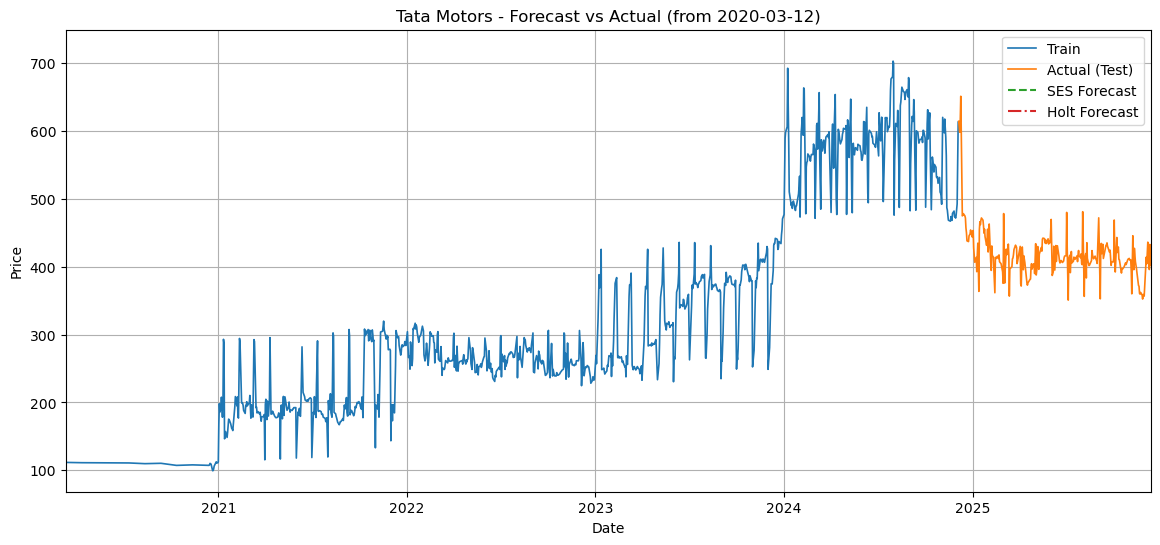

In [27]:
# Step 14A (updated): Forecast vs Actual plot - Tata (focused window)
# Default recent start date (change if you want a different window)
start_date = pd.Timestamp('2020-02-01')

# Ensure the expected objects exist
if 'tata_train' not in globals() or 'tata_test' not in globals() or 'tata_ses_pred' not in globals() or 'tata_holt_pred' not in globals():
    print("Tata forecast objects not found. Make sure you ran Train/Test, SES and Holt steps for Tata.")
else:
    # compute effective start: the later of start_date or some recent point in the train
    eff_start = max(start_date, tata_train.index.min())
    # but ensure we have some context: if eff_start is after the last test date, fallback to train start
    if eff_start > tata_test.index.max():
        eff_start = tata_train.index.min()

    # assemble a combined Series for plotting (train+test+preds have datetime indices)
    plt.figure(figsize=(14,6))
    # plot full train (but we will limit xlim)
    plt.plot(tata_train.index, tata_train, label='Train', linewidth=1.2)
    plt.plot(tata_test.index, tata_test, label='Actual (Test)', linewidth=1.2)
    plt.plot(tata_ses_pred.index, tata_ses_pred, label='SES Forecast', linestyle='--')
    plt.plot(tata_holt_pred.index, tata_holt_pred, label='Holt Forecast', linestyle='-.')
    plt.title(f"{tata_key} - Forecast vs Actual (from {eff_start.date()})")
    plt.xlabel("Date"); plt.ylabel("Price")
    plt.legend(); plt.grid(True); 
    try:
        plt.xlim(eff_start, tata_test.index.max())
    except Exception:
        pass
    plt.show()




# 14B. Forecast vs Actual Plot — Mahindra (focused recent window)
Plot Train, Actual (Test), SES and Holt forecasts for Mahindra with the same focused window (default start = 2020-02-01).


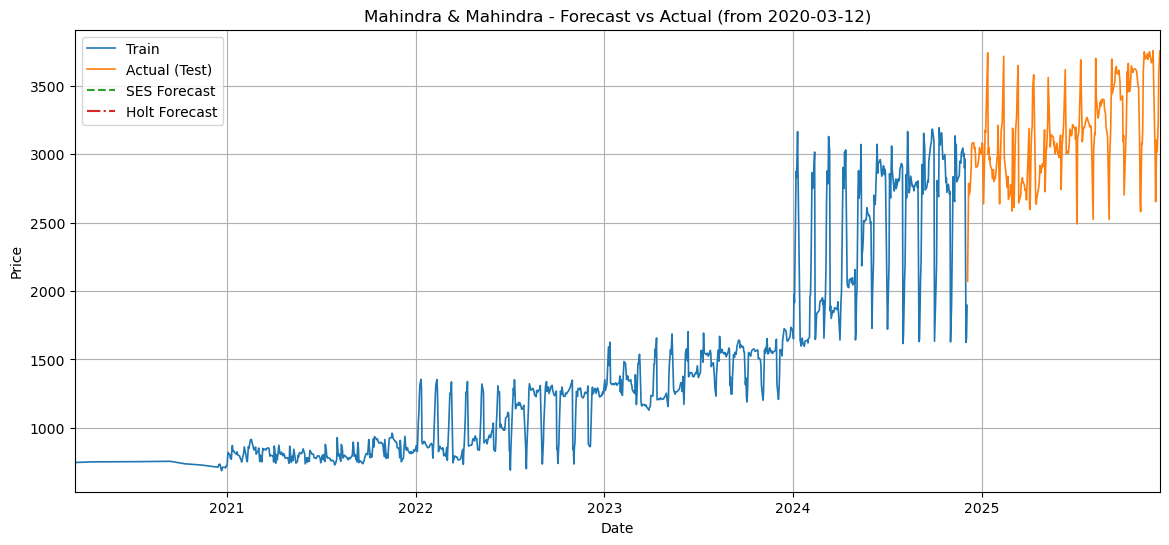

In [28]:
# Step 14B (updated): Forecast vs Actual plot - Mahindra (focused window)
start_date = pd.Timestamp('2020-02_01'.replace('_','-'))  # easy to change

if 'mah_train' not in globals() or 'mah_test' not in globals() or 'mah_ses_pred' not in globals() or 'mah_holt_pred' not in globals():
    print("Mahindra forecast objects not found. Make sure you ran Train/Test, SES and Holt steps for Mahindra.")
else:
    eff_start = max(start_date, mah_train.index.min())
    if eff_start > mah_test.index.max():
        eff_start = mah_train.index.min()

    plt.figure(figsize=(14,6))
    plt.plot(mah_train.index, mah_train, label='Train', linewidth=1.2)
    plt.plot(mah_test.index, mah_test, label='Actual (Test)', linewidth=1.2)
    plt.plot(mah_ses_pred.index, mah_ses_pred, label='SES Forecast', linestyle='--')
    plt.plot(mah_holt_pred.index, mah_holt_pred, label='Holt Forecast', linestyle='-.')
    plt.title(f"{mahindra_key} - Forecast vs Actual (from {eff_start.date()})")
    plt.xlabel("Date"); plt.ylabel("Price")
    plt.legend(); plt.grid(True)
    try:
        plt.xlim(eff_start, mah_test.index.max())
    except Exception:
        pass
    plt.show()


# 15A. RMSE Comparison & Model Summary — Tata
Print SES and Holt RMSE/MAE/MAPE for Tata. (No changes — just placed after the improved plots.)


In [29]:
# Step 15A: RMSE summary - Tata (unchanged)
if 'tata_ses_rmse' in globals() and 'tata_holt_rmse' in globals():
    print("Tata SES -> RMSE: {:.4f}, MAE: {:.4f}, MAPE(%): {:.4f}".format(tata_ses_rmse, tata_ses_mae, tata_ses_mape))
    print("Tata Holt-> RMSE: {:.4f}, MAE: {:.4f}, MAPE(%): {:.4f}".format(tata_holt_rmse, tata_holt_mae, tata_holt_mape))
else:
    print("Tata metrics not available. Ensure SES/Holt steps have run for Tata.")


Tata SES -> RMSE: 169.7432, MAE: 166.4592, MAPE(%): 40.5689
Tata Holt-> RMSE: 241.4600, MAE: 233.5797, MAPE(%): 56.9989


# 15B. RMSE Comparison & Model Summary — Mahindra
Print SES and Holt RMSE/MAE/MAPE for Mahindra.



In [30]:
# Step 15B: RMSE summary - Mahindra (unchanged)
if 'mah_ses_rmse' in globals() and 'mah_holt_rmse' in globals():
    print("Mahindra SES -> RMSE: {:.4f}, MAE: {:.4f}, MAPE(%): {:.4f}".format(mah_ses_rmse, mah_ses_mae, mah_ses_mape))
    print("Mahindra Holt-> RMSE: {:.4f}, MAE: {:.4f}, MAPE(%): {:.4f}".format(mah_holt_rmse, mah_holt_mae, mah_holt_mape))
else:
    print("Mahindra metrics not available. Ensure SES/Holt steps have run for Mahindra.")


Mahindra SES -> RMSE: 1306.4266, MAE: 1265.0550, MAPE(%): 39.5571
Mahindra Holt-> RMSE: 1161.5123, MAE: 1125.0462, MAPE(%): 35.2034


# 16A. Diagnostic Table — Tata
Display diagnostic table (actual vs forecasts) and top rows with largest percentage errors for Tata.


In [31]:
# Step 16A: Diagnostic table - Tata (unchanged)
if 'tata_test' in globals() and 'tata_ses_pred' in globals() and 'tata_holt_pred' in globals():
    diag_tata = pd.DataFrame({'actual': tata_test, 'ses': tata_ses_pred, 'holt': tata_holt_pred})
    diag_tata['abs_pct_error_ses'] = (diag_tata['ses'] - diag_tata['actual']).abs() / diag_tata['actual'].abs() * 100
    diag_tata['abs_pct_error_holt'] = (diag_tata['holt'] - diag_tata['actual']).abs() / diag_tata['actual'].abs() * 100
    diag_tata = diag_tata.replace([np.inf, -np.inf], np.nan)
    display(diag_tata.sort_values(by='abs_pct_error_ses', ascending=False).head(10))
else:
    print("Tata diagnostics not available. Run forecast steps first.")


,actual,ses,holt,abs_pct_error_ses,abs_pct_error_holt
2024-12-04 00:00:00,614.68,NaN,NaN,NaN,NaN
2024-12-06 00:00:00,598.53,NaN,NaN,NaN,NaN
2024-12-07 00:00:00,615.51,NaN,NaN,NaN,NaN
2024-12-08 00:00:00,651.47,NaN,NaN,NaN,NaN
2024-12-09 00:00:00,596.99,NaN,NaN,NaN,NaN
2024-12-11 00:00:00,475.13,NaN,NaN,NaN,NaN
2024-12-12 00:00:00,476.04,NaN,NaN,NaN,NaN
2024-12-13 00:00:00,478.43,NaN,NaN,NaN,NaN
2024-12-16 00:00:00,475.10,NaN,NaN,NaN,NaN
2024-12-17 00:00:00,472.04,NaN,NaN,NaN,NaN


# 16B. Diagnostic Table — Mahindra
Display diagnostic table (actual vs forecasts) and top rows with largest percentage errors for Mahindra.


In [32]:
# Step 16B: Diagnostic table - Mahindra (unchanged)
if 'mah_test' in globals() and 'mah_ses_pred' in globals() and 'mah_holt_pred' in globals():
    diag_mah = pd.DataFrame({'actual': mah_test, 'ses': mah_ses_pred, 'holt': mah_holt_pred})
    diag_mah['abs_pct_error_ses'] = (diag_mah['ses'] - diag_mah['actual']).abs() / diag_mah['actual'].abs() * 100
    diag_mah['abs_pct_error_holt'] = (diag_mah['holt'] - diag_mah['actual']).abs() / diag_mah['actual'].abs() * 100
    diag_mah = diag_mah.replace([np.inf, -np.inf], np.nan)
    display(diag_mah.sort_values(by='abs_pct_error_ses', ascending=False).head(10))
else:
    print("Mahindra diagnostics not available. Run forecast steps first.")


,actual,ses,holt,abs_pct_error_ses,abs_pct_error_holt
2024-12-04 00:00:00,2070.95,NaN,NaN,NaN,NaN
2024-12-06 00:00:00,2787.55,NaN,NaN,NaN,NaN
2024-12-07 00:00:00,2703.95,NaN,NaN,NaN,NaN
2024-12-08 00:00:00,2717.65,NaN,NaN,NaN,NaN
2024-12-09 00:00:00,2740.90,NaN,NaN,NaN,NaN
2024-12-11 00:00:00,2898.55,NaN,NaN,NaN,NaN
2024-12-12 00:00:00,3067.45,NaN,NaN,NaN,NaN
2024-12-13 00:00:00,3081.40,NaN,NaN,NaN,NaN
2024-12-16 00:00:00,3084.85,NaN,NaN,NaN,NaN
2024-12-17 00:00:00,3041.50,NaN,NaN,NaN,NaN


# 17. Per-company wrapper (optional)
A convenience wrapper that runs the full per-company pipeline and returns results. (No change required.)


In [33]:
# Step 17: Per-company wrapper (redefine/confirm)
def run_analysis_for_key(key, start_window=pd.Timestamp('2020-02-01'), show_plots=True):
    # expects companies_clean[key] present
    dfc = companies_clean[key].copy()
    dfc = add_derived_features(dfc)
    inferred = pd.infer_freq(dfc.index)
    if inferred is None:
        dfc = dfc.asfreq('B'); dfc['Price'] = dfc['Price'].ffill()
    train, test = train_test_split_series(dfc)
    ses_m, ses_p, ses_metrics = fit_ses(train, test)
    holt_m, holt_p, holt_metrics = fit_holt(train, test)
    # plotting focused
    eff_start = max(start_window, train.index.min())
    if eff_start > test.index.max():
        eff_start = train.index.min()
    if show_plots:
        plt.figure(figsize=(14,6))
        plt.plot(train.index, train, label='Train')
        plt.plot(test.index, test, label='Actual (Test)')
        plt.plot(ses_p.index, ses_p, label='SES', linestyle='--')
        plt.plot(holt_p.index, holt_p, label='Holt', linestyle='-.')
        plt.title(f"{key} - Forecast vs Actual (from {eff_start.date()})")
        plt.xlabel("Date"); plt.ylabel("Price")
        plt.legend(); plt.grid(True)
        try:
            plt.xlim(eff_start, test.index.max())
        except Exception:
            pass
        plt.show()
    return {'df': dfc, 'train': train, 'test': test, 'ses_pred': ses_p, 'holt_pred': holt_p,
            'ses_metrics': ses_metrics, 'holt_metrics': holt_metrics}

print("run_analysis_for_key available (use start_window param to change focused window).")


run_analysis_for_key available (use start_window param to change focused window).


# 18. Comparative Analysis — Metrics & Overlay Charts
Build a comparative metrics table and show overlay charts; overlay plots are also focused on the recent window by default.


,SES_RMSE,SES_MAE,SES_MAPE,Holt_RMSE,Holt_MAE,Holt_MAPE
Company,,,,,,
Tata Motors,169.743244,166.459180,40.568882,241.459966,233.579690,56.998946
Mahindra & Mahindra,1306.426632,1265.054984,39.557129,1161.512348,1125.046213,35.203378


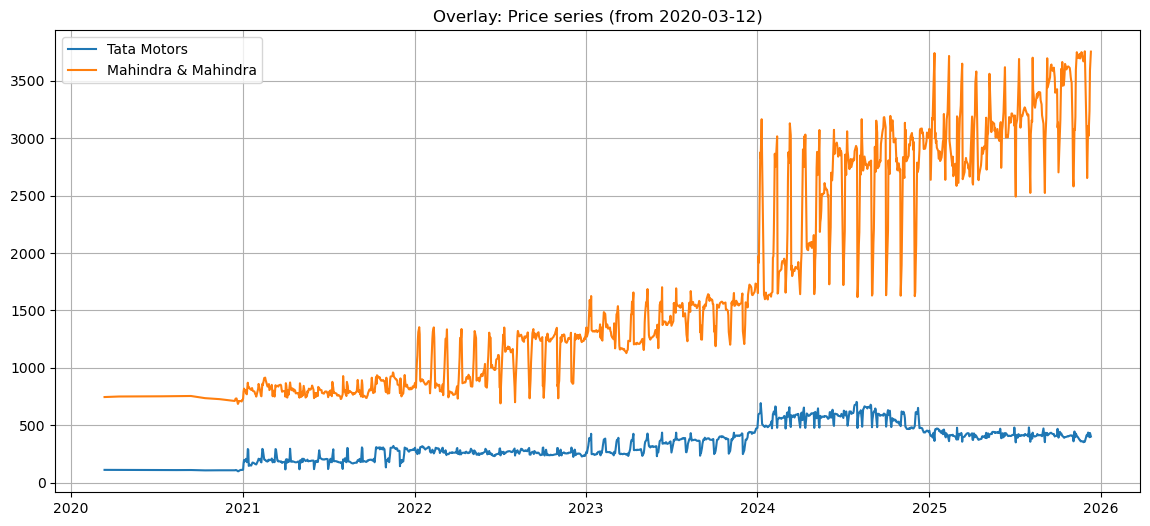

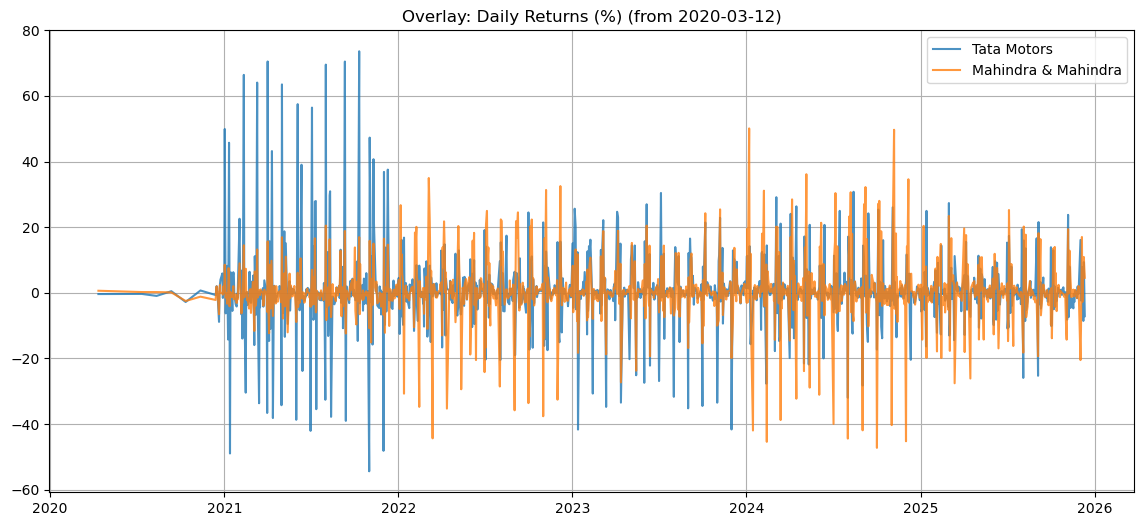

,Tata Motors,Mahindra & Mahindra
Tata Motors,1.000000,0.307499
Mahindra & Mahindra,0.307499,1.000000


In [34]:
# Step 18: Comparative metrics & overlay charts (updated to focus on recent window)
# build results if not already available (safe retrieval)
try:
    # ensure per-company preds/metrics exist; if not, compute using wrapper
    if 'tata_ses_pred' not in globals() or 'tata_holt_pred' not in globals():
        res_tata = run_analysis_for_key(tata_key, start_window=pd.Timestamp('2020-02-01'), show_plots=False)
        # assign back to variables for backward compatibility
        tata_train, tata_test = res_tata['train'], res_tata['test']
        tata_ses_pred = res_tata['ses_pred']; tata_holt_pred = res_tata['holt_pred']
        tata_ses_rmse = res_tata['ses_metrics']['RMSE']; tata_holt_rmse = res_tata['holt_metrics']['RMSE']
        tata_ses_mae = res_tata['ses_metrics']['MAE']; tata_holt_mae = res_tata['holt_metrics']['MAE']
        tata_ses_mape = res_tata['ses_metrics']['MAPE']; tata_holt_mape = res_tata['holt_metrics']['MAPE']
    if 'mah_ses_pred' not in globals() or 'mah_holt_pred' not in globals():
        res_mah = run_analysis_for_key(mahindra_key, start_window=pd.Timestamp('2020-02-01'), show_plots=False)
        mah_train, mah_test = res_mah['train'], res_mah['test']
        mah_ses_pred = res_mah['ses_pred']; mah_holt_pred = res_mah['holt_pred']
        mah_ses_rmse = res_mah['ses_metrics']['RMSE']; mah_holt_rmse = res_mah['holt_metrics']['RMSE']
        mah_ses_mae = res_mah['ses_metrics']['MAE']; mah_holt_mae = res_mah['holt_metrics']['MAE']
        mah_ses_mape = res_mah['ses_metrics']['MAPE']; mah_holt_mape = res_mah['holt_metrics']['MAPE']
except Exception as e:
    print("Error computing per-company results for comparison (will try to proceed with available variables):", e)

# Build metrics DataFrame
metrics_rows = []
for k in [tata_key, mahindra_key]:
    if k == tata_key:
        metrics_rows.append({'Company': k, 'SES_RMSE': tata_ses_rmse, 'SES_MAE': tata_ses_mae, 'SES_MAPE': tata_ses_mape,
                             'Holt_RMSE': tata_holt_rmse, 'Holt_MAE': tata_holt_mae, 'Holt_MAPE': tata_holt_mape})
    else:
        metrics_rows.append({'Company': k, 'SES_RMSE': mah_ses_rmse, 'SES_MAE': mah_ses_mae, 'SES_MAPE': mah_ses_mape,
                             'Holt_RMSE': mah_holt_rmse, 'Holt_MAE': mah_holt_mae, 'Holt_MAPE': mah_holt_mape})
metrics_df = pd.DataFrame(metrics_rows).set_index('Company')
display(metrics_df)

# Overlay price focusing on the recent window
start_window = pd.Timestamp('2020-02-01')
eff_start = max(start_window, min(companies_clean[tata_key].index.min(), companies_clean[mahindra_key].index.min()))
plt.figure(figsize=(14,6))
for k in [tata_key, mahindra_key]:
    dfk = companies_clean[k]
    plt.plot(dfk.loc[eff_start:].index, dfk.loc[eff_start:]['Price'], label=k)
plt.title("Overlay: Price series (from {})".format(eff_start.date())); plt.legend(); plt.grid(True); plt.show()

# Overlay returns (same window)
plt.figure(figsize=(14,6))
for k in [tata_key, mahindra_key]:
    dfk = companies_clean[k]
    plt.plot(dfk.loc[eff_start:].index, dfk.loc[eff_start:]['Return']*100, label=k, alpha=0.8)
plt.title("Overlay: Daily Returns (%) (from {})".format(eff_start.date())); plt.legend(); plt.grid(True); plt.show()

# Returns correlation (align dates across full series)
ret_dfs = [companies_clean[tata_key]['Return'].rename(tata_key), companies_clean[mahindra_key]['Return'].rename(mahindra_key)]
returns_df = pd.concat(ret_dfs, axis=1)
display(returns_df.corr())


# 19. Save Outputs (CSV)
Save cleaned datasets, diagnostics and comparative metrics to `/mnt/data/ts_analysis_outputs`.


In [35]:
# Step 19: Save outputs (unchanged)
out_dir = "/mnt/data/ts_analysis_outputs"
os.makedirs(out_dir, exist_ok=True)
metrics_df.to_csv(os.path.join(out_dir, "comparative_metrics.csv"))
try:
    diag_tata.to_csv(os.path.join(out_dir, f"{tata_key.replace(' ','_')}_diagnostics.csv"))
except Exception:
    pass
try:
    diag_mah.to_csv(os.path.join(out_dir, f"{mahindra_key.replace(' ','_')}_diagnostics.csv"))
except Exception:
    pass
companies_clean[tata_key].to_csv(os.path.join(out_dir, f"{tata_key.replace(' ','_')}_cleaned.csv"))
companies_clean[mahindra_key].to_csv(os.path.join(out_dir, f"{mahindra_key.replace(' ','_')}_cleaned.csv"))
print("Saved outputs to", out_dir)


Saved outputs to /mnt/data/ts_analysis_outputs
